# Multi-modal bone marrow integration with RegularizedMultimodalVI (early stopping)

This notebook uses `RegularizedMultimodalVI` with the same architecture as the main multimodal tutorial,
but with **early stopping** and **checkpoint saving** every 1000 epochs.

Training uses `train_size=0.9` (90/10 train/val split), `early_stopping_patience=20`,
and `max_epochs=5000` as upper bound.

Compare with:
- [bone_marrow_multimodal_tutorial.ipynb](bone_marrow_multimodal_tutorial.ipynb) — same model trained for 3500 epochs (no early stopping)


In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import torch
import mudata as mu

import scvi
import regularizedvi

# Simple text progress bar (works with papermill)
scvi.settings.progress_bar_style = "tqdm"

# Use high-precision matmul for better numerical stability on GPU
torch.set_float32_matmul_precision("high")

rcParams["pdf.fonttype"] = 42  # enables correct plotting of text for publication figures

## 1. Load data

Load the bone marrow multiome dataset. This dataset contains both GEX (gene expression)
and ATAC (chromatin accessibility) features in a single AnnData, distinguished by the
`feature_types` column in `.var`.

In [ ]:
import os

from regularizedvi.utils import download_bone_marrow_dataset

results_folder = "results/multimodal_tutorial_early_stopping/"
os.makedirs(results_folder, exist_ok=True)

h5ad_path = download_bone_marrow_dataset(data_folder="data/")
adata_full = sc.read_h5ad(h5ad_path)

print(adata_full)
print(f"\nFeature types: {adata_full.var['feature_types'].value_counts().to_dict()}")
print(f"Batches: {adata_full.obs['batch'].nunique()}")
print(f"Sites: {adata_full.obs['site'].nunique()}")
print(f"Donors: {adata_full.obs['donor'].nunique()}")

## 2. Quality control

Apply the same cell QC as the RNA-only tutorial: filter on UMI counts, genes detected,
ATAC fragments, mitochondrial fraction, and doublet score.

In [3]:
# Mitochondrial fraction (computed on GEX features)
gex_mask = adata_full.var["feature_types"] == "GEX"
adata_full.var["SYMBOL"] = adata_full.var_names.values.copy()

gex_adata = adata_full[:, gex_mask].copy()
gex_adata.var["mt"] = [gene.startswith("MT-") for gene in gex_adata.var["SYMBOL"]]
mt_counts = gex_adata[:, gex_adata.var["mt"].tolist()].X.sum(1).A.squeeze()
adata_full.obs["mt_frac"] = mt_counts / adata_full.obs["GEX_n_counts"]

del gex_adata

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


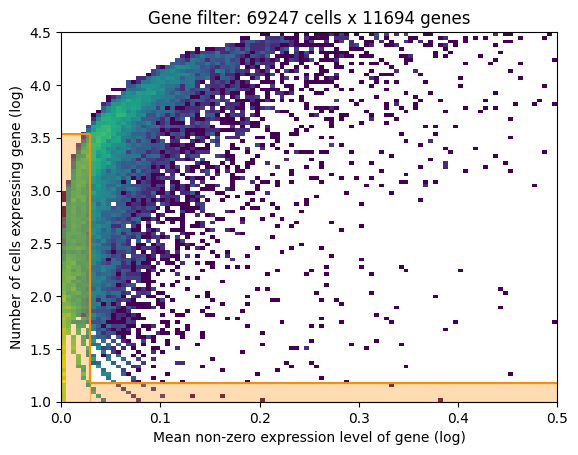

Fraction above 0.18 threshold: 0.025


In [4]:
# Doublet detection (on GEX)
from regularizedvi.utils import filter_genes

adata_gex_for_scrub = adata_full[:, gex_mask].copy()
adata_gex_for_scrub.var_names = adata_gex_for_scrub.var["gene_ids"].values.astype(str).copy()
adata_gex_for_scrub.X = adata_gex_for_scrub.layers["counts"]

selected = filter_genes(
    adata_gex_for_scrub,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.05,
    nonz_mean_cutoff=1.07,
)
adata_for_scrublet = adata_gex_for_scrub[:, selected].copy()
sc.pp.scrublet(
    adata_for_scrublet,
    batch_key="batch",
    n_prin_comps=40,
    verbose=False,
)
adata_full.obs["doublet_score"] = adata_for_scrublet.obs["doublet_score"]
del adata_gex_for_scrub, adata_for_scrublet

print(f"Fraction above 0.18 threshold: {(adata_full.obs['doublet_score'] > 0.18).mean():.3f}")

In [ ]:
# ATAC QC metrics

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(adata_full.obs["ATAC_atac_fragments"], bins=100, edgecolor="black", linewidth=0.3)
axes[0].axvline(2000, color="red", linestyle="--", label="threshold = 2000")
axes[0].set_xlabel("ATAC fragments")
axes[0].set_ylabel("Cells")
axes[0].set_title("ATAC fragments per cell")
axes[0].legend()

axes[1].hist(adata_full.obs["ATAC_atac_fragments"].clip(upper=20000), bins=100, edgecolor="black", linewidth=0.3)
axes[1].axvline(2000, color="red", linestyle="--", label="threshold = 2000")
axes[1].set_xlabel("ATAC fragments (clipped at 20k)")
axes[1].set_ylabel("Cells")
axes[1].set_title("ATAC fragments (zoomed)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Cells with ATAC fragments <= 2000: {(adata_full.obs['ATAC_atac_fragments'] <= 2000).sum()}")
print(f"Cells with ATAC fragments <= 1000: {(adata_full.obs['ATAC_atac_fragments'] <= 1000).sum()}")

In [ ]:
# Cell filtering
n_before = adata_full.n_obs
cell_mask = (
    (adata_full.obs["GEX_n_genes"] > 500)
    & (adata_full.obs["GEX_n_counts"] > 1000)
    & (adata_full.obs["GEX_n_counts"] < 80000)
    & (adata_full.obs["GEX_n_genes"] < 10000)
    & (adata_full.obs["ATAC_atac_fragments"] > 2000)
    & (adata_full.obs["ATAC_atac_fragments"] < 100000)
    & (adata_full.obs["mt_frac"] < 0.20)
    & (adata_full.obs["doublet_score"] < 0.18)
)
adata_full = adata_full[cell_mask, :].copy()
print(f"Filtered {n_before} -> {adata_full.n_obs} cells ({n_before - adata_full.n_obs} removed)")

## 3. Split into RNA and ATAC modalities

Split the combined AnnData into separate modalities for MuData creation.

In [6]:
# Split by feature type
gex_mask = adata_full.var["feature_types"] == "GEX"
atac_mask = adata_full.var["feature_types"] == "ATAC"

adata_rna = adata_full[:, gex_mask].copy()
adata_atac = adata_full[:, atac_mask].copy()

# Use counts as X
adata_rna.X = adata_rna.layers["counts"]
adata_atac.X = adata_atac.layers["counts"]

# Use gene symbols for RNA var_names
adata_rna.var["SYMBOL"] = adata_rna.var_names.values.copy()
adata_rna.var_names = adata_rna.var["gene_ids"].values.astype(str).copy()

print(f"RNA: {adata_rna.shape}")
print(f"ATAC: {adata_atac.shape}")

RNA: (46534, 25629)
ATAC: (46534, 116490)


## 4. Feature selection

### RNA gene selection

Select informative genes using `filter_genes` (adapted from cell2location).

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


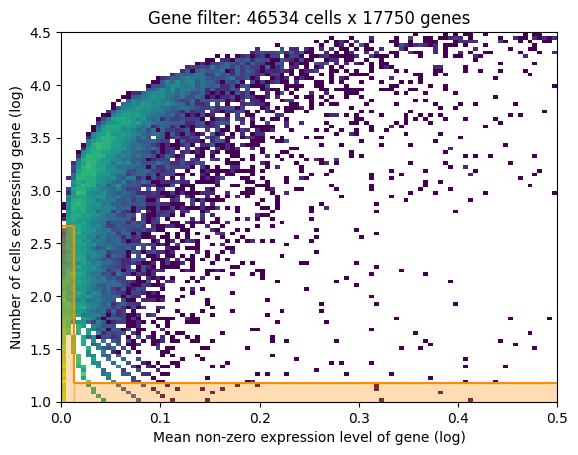

Selected 17750 RNA genes


In [7]:
selected_genes = filter_genes(
    adata_rna,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.01,
    nonz_mean_cutoff=1.03,
)
adata_rna = adata_rna[:, selected_genes].copy()
print(f"Selected {adata_rna.n_vars} RNA genes")

### ATAC peak selection

We use the same `filter_genes` tool for ATAC peaks. The ATAC data contains fragment
counts per peak per cell (not binary) — the most common non-zero value is 2 (both ends
of a sequencing fragment), with a typical non-zero mean of ~2–3 fragments.

The cutoffs operate the same way as for RNA:
- `cell_count_cutoff` — peaks accessible in at least this many cells (the lower tier)
- `cell_percentage_cutoff2` — peaks in at least this fraction of cells are always kept
- `nonz_mean_cutoff` — mean fragment count in accessible cells (filters low-signal peaks)

For ATAC peaks, `log10(nonz_mean) ≈ 0.3` (i.e. mean ≈ 2 fragments), so a lower
`nonz_mean_cutoff` than for RNA is appropriate.

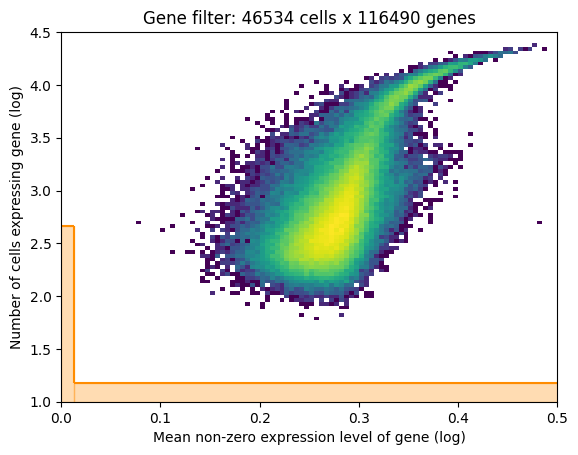

Selected 116490 ATAC peaks


In [8]:
selected_peaks = filter_genes(
    adata_atac,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.01,
    nonz_mean_cutoff=1.03,  # mean fragment count > 1.03 in accessible cells
)
adata_atac = adata_atac[:, selected_peaks].copy()
print(f"Selected {adata_atac.n_vars} ATAC peaks")

## 5. Create MuData

Combine the RNA and ATAC AnnData objects into a MuData for multi-modal modelling.

In [9]:
mdata = mu.MuData({"rna": adata_rna, "atac": adata_atac})
print(mdata)
print(f"\nRNA: {mdata.mod['rna'].shape}")
print(f"ATAC: {mdata.mod['atac'].shape}")

MuData object with n_obs × n_vars = 46534 × 134240
  var:	'gene_ids', 'feature_types', 'hvg_multiVI', 'SYMBOL', 'n_cells', 'nonz_mean'
  2 modalities
    rna:	46534 x 17750
      obs:	'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'GEX_pseudotime_order', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_pseudotime_order', 'DonorID', 'VendorLot', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'modality', 'site', 'donor', 'batch', 'l1_cell_type', 'l2_cell_type', 'neurips21_cell_type', 'old_neurips21_obs_names', 'frag_file_bcs', 'mt_frac', 'doublet_score'
      var:	'gene_ids', 'feature_types', 'hvg_multiVI', 'SYMBOL', 'n_cells', 'nonz_mean'
      uns:	'ATAC_gene_activity_var_names', '_scvi', 'dataset_id', 'genome', 'neighbors', 'organism', 'umap'
      obsm:	'ATAC_gene_activity', 'MultiVI_latent', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'dis

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/mudata/_core/mudata.py:904: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_common = pd.concat(
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/mudata/_core/mudata.py:904: FutureWarning: The behavior of Dat

## 6. Model setup

### The modality dictionary interface

`RegularizedMultimodalVI` uses a **dictionary convention** for per-modality configuration:

```python
# Scalar values apply to ALL modalities:
n_hidden=256  # both RNA and ATAC encoders/decoders have 256 hidden units

# Dict values are per-modality:
n_hidden={'rna': 512, 'atac': 256}  # RNA gets 512, ATAC gets 256
n_latent={'rna': 64, 'atac': 16}    # RNA encoder outputs 64-dim Z, ATAC outputs 16-dim Z
```

With `latent_mode='concatenation'` (default), the total latent dimension is the sum:
Z = [Z_rna (64); Z_atac (16)] = 80 dimensions. All decoders see the full 80-dim Z.

### Per-modality flags

Two lists control which modalities get special processing:

- `additive_background_modalities=['rna']` — ambient RNA correction for RNA only
  (ATAC has negligible ambient signal: ~0.1% of reads in empty droplets)
- `feature_scaling_modalities=['rna', 'atac']` — per-covariate, per-feature scaling factors
  (cell2location-style $y_{t,g}$: corrects for site/donor/technology effects on gene expression and peak accessibility)

### Separate covariate registration

`nn_conditioning_covariate_keys` go into the encoder/decoder (affect latent representation).
`feature_scaling_covariate_keys` only multiply the output rate (per-feature scaling).
Both can use the same columns — they serve different purposes.

In [ ]:
regularizedvi.RegularizedMultimodalVI.setup_mudata(
    mdata,
    ambient_covariate_keys=["batch"],
    nn_conditioning_covariate_keys=["site", "donor"],
    feature_scaling_covariate_keys=["site", "donor"],
    dispersion_key="batch",
    library_size_key="batch",
    encoder_covariate_keys=False,
)

### Per-covariate feature scaling (cell2location-style $y_{t,g}$)

The `feature_scaling_covariate_keys` parameter registers categorical covariates for
**per-covariate, per-feature scaling factors** — analogous to cell2location's `detection_tech_gene_tg`.

Each level of each covariate gets its own per-gene (or per-peak) scaling factor $y_{t,g}$:
- **Shape**: `(sum(n_categories), n_features)` per modality — e.g., 4 sites + 10 donors = 14 rows
- **Activation**: `softplus(param) / 0.7` — positive, centered at 1.0 when `param=0`
- **Prior**: `Gamma(200, 200)` — mean=1.0, very tight (std ≈ 0.07), keeps factors near 1 unless data demands otherwise
- **Indexing**: one-hot matrix multiplication selects the right row(s) per cell

These are **separate** from `nn_conditioning_covariate_keys` (which go into the encoder/decoder):
scaling covariates only multiply the output rate, not the latent representation.

Setting `feature_scaling_modalities=["rna", "atac"]` enables scaling for both modalities.

In [ ]:
# Papermill parameters
results_folder = "results/multimodal_tutorial_early_stopping/"
additive_bg_prior_alpha = 1.0
additive_bg_prior_beta = 100.0
regularise_background = 1
compute_pearson = 1
use_feature_scaling = 1
library_log_means_centering_sensitivity_rna = None
library_log_means_centering_sensitivity_atac = None
library_log_vars_weight = 0.05
library_log_vars_weight_atac = None
learnable_modality_scaling = 0
modality_scale_prior_concentration = 5.0
modality_lr_multiplier_atac = None
stratify_validation_key = None
early_stopping_min_delta_per_feature = None
skip_training = 0
max_epochs = 5000
wandb_project = None
wandb_name = None
wandb_entity = None
wandb_notes = None
decoder_weight_l2 = 0.0
init_decoder_bias = None
bg_init_gene_fraction = None
wandb_group = None

In [ ]:
from regularizedvi.utils import coerce_papermill_params, finish_wandb, log_figure_to_wandb, setup_wandb_logger

# Convert papermill params to correct types (papermill -r passes strings)
params = coerce_papermill_params(
    additive_bg_prior_alpha=(additive_bg_prior_alpha, float),
    additive_bg_prior_beta=(additive_bg_prior_beta, float),
    regularise_background=(regularise_background, bool),
    compute_pearson=(compute_pearson, bool),
    use_feature_scaling=(use_feature_scaling, bool),
    library_log_means_centering_sensitivity_rna=(library_log_means_centering_sensitivity_rna, "float_or_none"),
    library_log_means_centering_sensitivity_atac=(library_log_means_centering_sensitivity_atac, "float_or_none"),
    library_log_vars_weight=(library_log_vars_weight, float),
    library_log_vars_weight_atac=(library_log_vars_weight_atac, "float_or_none"),
    learnable_modality_scaling=(learnable_modality_scaling, bool),
    modality_scale_prior_concentration=(modality_scale_prior_concentration, float),
    modality_lr_multiplier_atac=(modality_lr_multiplier_atac, "float_or_none"),
    stratify_validation_key=(stratify_validation_key, "str_or_none"),
    early_stopping_min_delta_per_feature=(early_stopping_min_delta_per_feature, "float_or_none"),
    skip_training=(skip_training, bool),
    max_epochs=(max_epochs, int),
    decoder_weight_l2=(decoder_weight_l2, float),
    init_decoder_bias=(init_decoder_bias, "str_or_none"),
    bg_init_gene_fraction=(bg_init_gene_fraction, "float_or_none"),
    wandb_project=(wandb_project, "str_or_none"),
    wandb_name=(wandb_name, "str_or_none"),
    wandb_entity=(wandb_entity, "str_or_none"),
    wandb_notes=(wandb_notes, "str_or_none"),
    wandb_group=(wandb_group, "str_or_none"),
)
additive_bg_prior_alpha = params["additive_bg_prior_alpha"]
additive_bg_prior_beta = params["additive_bg_prior_beta"]
regularise_background = params["regularise_background"]
compute_pearson = params["compute_pearson"]
use_feature_scaling = params["use_feature_scaling"]
library_log_means_centering_sensitivity_rna = params["library_log_means_centering_sensitivity_rna"]
library_log_means_centering_sensitivity_atac = params["library_log_means_centering_sensitivity_atac"]
library_log_vars_weight = params["library_log_vars_weight"]
library_log_vars_weight_atac = params["library_log_vars_weight_atac"]
learnable_modality_scaling = params["learnable_modality_scaling"]
modality_scale_prior_concentration = params["modality_scale_prior_concentration"]
modality_lr_multiplier_atac = params["modality_lr_multiplier_atac"]
stratify_validation_key = params["stratify_validation_key"]
early_stopping_min_delta_per_feature = params["early_stopping_min_delta_per_feature"]
skip_training = params["skip_training"]
max_epochs = params["max_epochs"]
decoder_weight_l2 = params["decoder_weight_l2"]
init_decoder_bias = params["init_decoder_bias"]
bg_init_gene_fraction = params["bg_init_gene_fraction"]
wandb_project = params["wandb_project"]
wandb_name = params["wandb_name"]
wandb_entity = params["wandb_entity"]
wandb_notes = params["wandb_notes"]
wandb_group = params["wandb_group"]

# Build per-modality centering sensitivity dict (None values → skip that modality)
_sens = {}
if library_log_means_centering_sensitivity_rna is not None:
    _sens["rna"] = library_log_means_centering_sensitivity_rna
if library_log_means_centering_sensitivity_atac is not None:
    _sens["atac"] = library_log_means_centering_sensitivity_atac
library_log_means_centering_sensitivity = _sens or None

# Build per-modality library_log_vars_weight dict if ATAC override is specified
if library_log_vars_weight_atac is not None:
    library_log_vars_weight = {"rna": library_log_vars_weight, "atac": library_log_vars_weight_atac}

# Build modality_lr_multiplier dict (None = uniform LR)
modality_lr_multiplier = None
if modality_lr_multiplier_atac is not None:
    modality_lr_multiplier = {"atac": modality_lr_multiplier_atac}

# W&B experiment tracking (no-op when wandb_project is None)
wandb_loggers, wandb_run = setup_wandb_logger(
    wandb_project=wandb_project,
    wandb_name=wandb_name,
    wandb_entity=wandb_entity,
    wandb_notes=wandb_notes,
    wandb_group=wandb_group,
    config={
        "additive_bg_prior_alpha": additive_bg_prior_alpha,
        "additive_bg_prior_beta": additive_bg_prior_beta,
        "regularise_background": regularise_background,
        "compute_pearson": compute_pearson,
        "use_feature_scaling": use_feature_scaling,
        "library_log_means_centering_sensitivity": library_log_means_centering_sensitivity,
        "library_log_vars_weight": library_log_vars_weight,
        "learnable_modality_scaling": learnable_modality_scaling,
        "modality_scale_prior_concentration": modality_scale_prior_concentration,
        "modality_lr_multiplier": modality_lr_multiplier,
        "stratify_validation_key": stratify_validation_key,
        "early_stopping_min_delta_per_feature": early_stopping_min_delta_per_feature,
        "max_epochs": max_epochs,
        "n_hidden": {"rna": 512, "atac": 256},
        "n_latent": {"rna": 128, "atac": 64},
        "n_layers": 1,
        "latent_mode": "concatenation",
    },
    results_folder=results_folder,
)

In [ ]:
model = regularizedvi.RegularizedMultimodalVI(
    mdata,
    # Per-modality architecture sizes
    n_hidden={"rna": 512, "atac": 256},
    n_latent={"rna": 128, "atac": 64},
    n_layers=1,
    # Z combination: concatenation preserves modality-specific signal
    latent_mode="concatenation",
    # Per-modality flags
    additive_background_modalities=["rna"],  # ambient correction for RNA only
    feature_scaling_modalities=["rna", "atac"] if use_feature_scaling else [],  # per-covariate scaling
    # Dispersion
    dispersion="gene-batch",
    regularise_dispersion=True,
    # Background prior
    additive_bg_prior_alpha=additive_bg_prior_alpha,
    additive_bg_prior_beta=additive_bg_prior_beta,
    regularise_background=regularise_background,
    # Library centering
    library_log_means_centering_sensitivity=library_log_means_centering_sensitivity,
    library_log_vars_weight=library_log_vars_weight,
    # Learnable modality scaling
    learnable_modality_scaling=learnable_modality_scaling,
    modality_scale_prior_concentration=modality_scale_prior_concentration,
    # Pearson correlation metrics
    compute_pearson=compute_pearson,
    # Decoder regularisation and initialisation
    decoder_weight_l2=decoder_weight_l2,
    init_decoder_bias=init_decoder_bias,
    bg_init_gene_fraction=bg_init_gene_fraction,
)

print(model)
print(f"\nTotal latent dim: {model.module.total_latent_dim}")
print(f"  RNA Z dim: {model.module.n_latent_dict['rna']}")
print(f"  ATAC Z dim: {model.module.n_latent_dict['atac']}")
print(f"\nRegion factors modalities: {model.module.feature_scaling_modalities}")
for name in model.module.feature_scaling:
    print(f"  {name} feature scaling shape: {model.module.feature_scaling[name].shape}")
print(f"\nRegularise background: {regularise_background}")
if regularise_background:
    print(f"  Prior: Gamma({additive_bg_prior_alpha}, {additive_bg_prior_beta})")
    print(f"  Prior mean: {additive_bg_prior_alpha / additive_bg_prior_beta:.4f}")
print(f"Library centering sensitivity: {library_log_means_centering_sensitivity}")
print(f"Library log vars weight: {library_log_vars_weight}")
print(f"Learnable modality scaling: {learnable_modality_scaling}")
if learnable_modality_scaling:
    for name in model.module.modality_scale_init:
        print(f"  {name} init: {model.module.modality_scale_init[name]:.3f}")
print(f"Compute Pearson: {compute_pearson}")

## 7. Train (early stopping)

Training uses `train_size=0.9` (90/10 train/val split) with early stopping
monitoring `elbo_validation` (patience=20). Checkpoints are saved every 1000 epochs.
The `max_epochs=5000` serves as an upper bound.


In [ ]:
import time

if skip_training:
    # Load previously trained model
    ref_run_name = f"{results_folder}/model"
    model = regularizedvi.RegularizedMultimodalVI.load(ref_run_name, adata=mdata)
    print(f"Loaded model from {ref_run_name}")
    n_epochs = len(model.history_["elbo_train"])
    print(f"Model was trained for {n_epochs} epochs")
else:
    from scvi.train import SaveCheckpoint

    checkpoint_cb = SaveCheckpoint(
        dirpath=f"{results_folder}/checkpoints",
        every_n_epochs=1000,
        save_top_k=-1,
        filename="epoch-{epoch}",
    )

    # Build early stopping kwargs (None = use auto-scaled default)
    _es_kwargs = {}
    if early_stopping_min_delta_per_feature is not None:
        _es_kwargs["early_stopping_min_delta_per_feature"] = early_stopping_min_delta_per_feature

    # Build plan_kwargs for per-modality LR (None = uniform LR)
    _plan_kwargs = {}
    if modality_lr_multiplier is not None:
        _plan_kwargs["modality_lr_multiplier"] = modality_lr_multiplier

    # Stratified train/val split (ensures cell types and batches are proportionally represented)
    _ds_kwargs = {}
    if stratify_validation_key is not None:
        import numpy as np
        from sklearn.model_selection import train_test_split

        obs_df = mdata.mod[list(mdata.mod.keys())[0]].obs
        keys = stratify_validation_key.split("+")
        strat_labels = obs_df[keys[0]].astype(str)
        for k in keys[1:]:
            strat_labels = strat_labels + "_" + obs_df[k].astype(str)
        # Merge rare strata (< 2 cells) to avoid sklearn errors
        counts = strat_labels.value_counts()
        rare = counts[counts < 2].index
        if len(rare) > 0:
            strat_labels = strat_labels.replace(rare, "_rare_")
            print(f"Merged {len(rare)} rare strata into '_rare_'")
        all_idx = np.arange(mdata.n_obs)
        train_idx, val_idx = train_test_split(all_idx, test_size=0.1, stratify=strat_labels.values, random_state=42)
        _ds_kwargs["external_indexing"] = [train_idx, val_idx]
        print(f"Stratified split by {stratify_validation_key}: {len(train_idx)} train, {len(val_idx)} val")

    t0 = time.time()
    model.train(
        check_val_every_n_epoch=1,
        train_size=0.9,
        max_epochs=max_epochs,
        batch_size=1024,
        early_stopping=True,
        early_stopping_patience=20,
        early_stopping_monitor="elbo_validation",
        enable_checkpointing=True,
        callbacks=[checkpoint_cb],
        logger=wandb_loggers,
        datasplitter_kwargs=_ds_kwargs if _ds_kwargs else None,
        plan_kwargs=_plan_kwargs if _plan_kwargs else None,
        **_es_kwargs,
    )
    elapsed = time.time() - t0

    n_epochs = len(model.history_["elbo_train"])
    print(f"\nTraining finished: {n_epochs} epochs in {elapsed / 60:.1f} min ({elapsed / n_epochs:.2f} s/epoch)")
    print(f"Throughput: {mdata.n_obs * n_epochs / elapsed:.0f} cells·epochs/s")

In [ ]:
# Save model
ref_run_name = f"{results_folder}/model"
model.save(ref_run_name, overwrite=True)

In [ ]:
fig = model.plot_training_diagnostics(skip_epochs=min(80, n_epochs // 2))
log_figure_to_wandb("training_diagnostics", fig)
plt.show()

## 8. Three paths to UMAP

With `latent_mode='concatenation'`, Z = [Z_rna; Z_atac]. The `get_modality_latents()` method
extracts the full joint representation and splits it into per-modality slices automatically.

This reveals which aspects of cell identity are captured by each modality:
- **Joint Z** — the complete picture, integrating both modalities
- **RNA Z** — transcriptomic structure (gene expression programs)
- **ATAC Z** — epigenomic structure (chromatin accessibility programs)

Cells that cluster together in RNA Z but separate in ATAC Z (or vice versa) indicate
modality-specific biology — the key advantage of the concatenation strategy over
weighted mean approaches.

In [ ]:
model.compute_latent_umap(adata_rna)
print("Computed joint + per-modality latent UMAPs")

### Per-modality UMAP comparison

Compare all three embeddings (joint Z, RNA Z, ATAC Z) coloured by batch and cell type
to see which modality drives which aspects of cell identity.

In [ ]:
fig = model.plot_umap_comparison(
    adata_rna,
    color=["site", "batch", "l1_cell_type", "l2_cell_type"],
    umap_keys=[
        ("X_umap_joint", "Joint Z"),
        ("X_umap_rna", "RNA Z"),
        ("X_umap_atac", "ATAC Z"),
    ],
)
log_figure_to_wandb("umap_3x4", fig)
plt.show()

In [ ]:
# UMAP coloured by QC technical variables
color_qc = ["GEX_n_counts", "GEX_n_genes", "ATAC_atac_fragments", "mt_frac", "doublet_score"]
color_qc = [c for c in color_qc if c in adata_rna.obs.columns]

rcParams["figure.figsize"] = 7, 7
sc.pl.embedding(
    adata_rna,
    basis="X_umap_joint",
    color=color_qc,
    color_map="RdPu",
    ncols=1,
    size=3,
    vmin=0,
    vmax="p99.9",
    use_raw=False,
)
plt.show()

In [ ]:
# UMAP coloured by batch, site, and cell type annotations
color = ["site", "batch", "l1_cell_type", "l2_cell_type"]

rcParams["figure.figsize"] = 7, 7
sc.pl.embedding(
    adata_rna,
    basis="X_umap_joint",
    color=color,
    color_map="RdPu",
    ncols=1,
    palette=sc.pl.palettes.default_102 + sc.pl.palettes.zeileis_28 + sc.pl.palettes.vega_20_scanpy,
    size=3,
    vmin=0,
    vmax="p99.9",
    gene_symbols="SYMBOL",
    use_raw=False,
    legend_fontsize=10,
)

### Load a previously trained model (optional)

If you have already trained the model and saved checkpoints, you can skip the training
cell above and load directly from a checkpoint. Uncomment the cell below and adjust the
epoch number to match your saved checkpoint.

In [ ]:
# To load a previously trained model without retraining:
# model = regularizedvi.RegularizedMultimodalVI.load(f"{results_folder}/checkpoints/epoch-XXXX/", adata=mdata)

## 8b. Decoder attribution analysis (Jacobian-based)

Which latent dimensions does each decoder actually use? We compute the **mean absolute Jacobian**
`|d(px_rate)/d(z)|` per latent dimension for each modality's decoder via finite differences.
This reveals which parts of the shared Z = [Z_rna; Z_atac] inform each modality.

The method returns two things per modality:
- **`attribution`** (n_cells, n_latent) — raw decoder sensitivity per latent dim. Can be analysed directly.
- **`weighted_z`** (n_cells, n_latent) — `z * attribution`, a modality-specific view of the latent space.

**What to look for**:
- If the RNA decoder uses primarily Z_rna dims (first 128) and ATAC decoder uses primarily Z_atac dims (last 64),
  the modalities learned independent representations.
- If the ATAC decoder relies heavily on Z_rna dims, this indicates **free-riding**: the ATAC decoder uses
  RNA-derived cell-type information rather than learning from chromatin data.
- Differences in **attribution UMAPs** between modalities highlight which cell populations are driven by
  RNA vs ATAC biology.

In [ ]:
attribution, fig_bar = model.plot_modality_attribution(batch_size=256)
log_figure_to_wandb("attribution_bar", fig_bar)
plt.show()

### Attribution-weighted UMAPs

The **weighted Z** (`z * attribution`) emphasises latent dimensions that each decoder actually uses.
UMAP on weighted Z provides a view of cell heterogeneity *as seen by each decoder*.

Differences between RNA and ATAC attribution UMAPs reveal cells that are driven by
different modalities — the key biological question for multiome data.

In [ ]:
attribution = model.store_attribution_results(adata_rna, attribution=attribution)
model.compute_attribution_umap(adata_rna)
print("Computed attribution-weighted UMAPs")

In [ ]:
# RNA vs ATAC attribution on joint UMAP
fig = model.plot_attribution_scatter(adata_rna, basis="X_umap_joint", size=2)
log_figure_to_wandb("attribution_scatter_joint", fig)
plt.show()

In [ ]:
fig = model.plot_umap_comparison(
    adata_rna,
    color=["batch", "l2_cell_type"],
    umap_keys=[
        ("X_umap_joint", "Joint Z"),
        ("X_umap_rna", "RNA Z"),
        ("X_umap_atac", "ATAC Z"),
        ("X_umap_attr_atac", "ATAC attribution Z"),
        ("X_umap_attr_rna", "RNA attribution Z"),
    ],
    figsize_per_panel=(5, 5),
)
log_figure_to_wandb("umap_summary_5x2", fig)
plt.show()

In [ ]:
# QC technical variables on all 5 UMAP embeddings
fig = model.plot_umap_comparison(
    adata_rna,
    color=["GEX_n_counts", "GEX_n_genes", "ATAC_atac_fragments", "mt_frac", "doublet_score"],
    umap_keys=[
        ("X_umap_joint", "Joint Z"),
        ("X_umap_rna", "RNA Z"),
        ("X_umap_atac", "ATAC Z"),
        ("X_umap_attr_atac", "ATAC attribution Z"),
        ("X_umap_attr_rna", "RNA attribution Z"),
    ],
    figsize_per_panel=(5, 5),
)
log_figure_to_wandb("umap_summary_5x5_qc", fig)
plt.show()

## 9. Marker gene visualisation

Overlay marker genes on the **Joint Z** UMAP to verify that the multi-modal latent
space captures expected biology.

In [ ]:
import pathlib

# Use joint UMAP for marker visualisation
adata_rna.obsm["X_umap"] = adata_rna.obsm["X_umap_joint"]

# Load marker genes
_nb_dir = pathlib.Path("docs/notebooks")
if not _nb_dir.exists():
    _nb_dir = pathlib.Path(".")
marker_df = pd.read_csv(_nb_dir / "known_marker_genes.csv")
categories = marker_df.groupby("category", sort=False)["gene"].apply(lambda x: list(dict.fromkeys(x)))

rcParams["figure.figsize"] = 6, 6

for category, gene_list in categories.items():
    present = [g for g in gene_list if g in adata_rna.var["SYMBOL"].values]
    if not present:
        continue

    gene_idx = adata_rna.var["SYMBOL"].isin(present)
    selected_expr = adata_rna[:, gene_idx].X.multiply(1.0 / adata_rna.obs[["GEX_n_counts"]].values)
    selected_expr = selected_expr.toarray() * 1e4

    col_names = [f"{m} normalised" for m in present]
    adata_rna.obs[col_names] = selected_expr

    print(f"\n{'=' * 60}")
    print(f"{category} ({len(present)} genes)")
    print(f"{'=' * 60}")

    sc.pl.umap(
        adata_rna,
        color=col_names,
        color_map="RdPu",
        ncols=5,
        size=3,
        vmin=0,
        vmax="p99.99",
        use_raw=False,
        legend_fontsize=8,
        title=[f"{m}" for m in present],
    )

## 10. Save outputs

In [ ]:
output_dir = f"{ref_run_name}/outputs/"
saved = model.save_analysis_outputs(
    output_dir,
    adata_rna,
    save_attribution=True,
    attribution=attribution,
)
print(f"Saved {len(saved)} files to {output_dir}")

In [ ]:
finish_wandb()

## Summary

This notebook demonstrated **RegularizedMultimodalVI** with early stopping for joint RNA + ATAC integration:

1. **Data preparation** — split multiome AnnData into separate RNA and ATAC modalities, select informative features, create MuData
2. **Model configuration** — per-modality architecture sizes via dict interface (`n_hidden`, `n_latent`), per-modality flags (`additive_background_modalities`, `feature_scaling_modalities`)
3. **Training** — standard scvi-tools training loop with multi-modal loss
4. **Per-modality diagnostics** — recon_loss, KL divergence, and Z variance per modality to assess training dynamics
5. **Three UMAP views** — joint Z, RNA-only Z, and ATAC-only Z reveal modality-specific and shared cell identity
6. **Decoder attribution analysis** — Jacobian-based attribution reveals which Z dims each decoder uses, enabling modality-specific views of cell heterogeneity

### Key design choices

- **GammaPoisson for ATAC** — count-based likelihood handles binary peak data naturally (0 and 1 are valid counts). More flexible than Bernoulli: can model count variation in fragment-level ATAC data.
- **Concatenation mode** — Z = [Z_rna; Z_atac] preserves modality-specific signal. Cells differing in chromatin but not transcriptome will separate in ATAC Z but not RNA Z.
- **Per-modality n_latent** — RNA typically gets more latent dimensions (higher feature complexity) while ATAC gets fewer (lower effective dimensionality).
- **No adversarial training** — simpler optimisation, relies on shared architecture and batch correction instead.
- **Attribution analysis** — post-training Jacobian attribution identifies modality contributions without modifying the model.

### Alternative Z strategies

```python
# Weighted mean (MultiVI-style) — single shared Z, n_latent must be equal
model = RegularizedMultimodalVI(mdata, latent_mode='weighted_mean', n_latent=64)

# Single encoder — one encoder for concatenated input
model = RegularizedMultimodalVI(mdata, latent_mode='single_encoder')
```